In [61]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
%matplotlib widget


# Trackmate data

In [62]:
filepaths = [f'/Volumes/phy/Gladfelter_rotation/Michael_Ursa/20240620_NaCl-gradient_24hr/3_results/s01_overnight_C_5NaCl_10NaCl_P{p}/output_masks_spots_P{p}.csv' for p in range(1, 10)]


In [63]:
pos = 1
filepath = filepaths[pos-1]

df = pd.read_csv(filepath, skiprows=[1, 2, 3])
df

,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,...,ELLIPSE_Y0,ELLIPSE_MAJOR,ELLIPSE_MINOR,ELLIPSE_THETA,ELLIPSE_ASPECTRATIO,AREA,PERIMETER,CIRCULARITY,SOLIDITY,SHAPE_INDEX
0,ID27009,27009,1,1303.0,959.364164,140.604941,0.0,21.0,21,20.385131,...,0.025998,23.060525,18.240805,2.689064,1.264227,1305.5,135.494180,0.893605,0.977171,3.750008
1,ID25730,25730,1,1405.0,965.507576,133.574811,0.0,0.0,0,21.170270,...,0.206752,23.351502,19.537062,0.748172,1.195241,1408.0,140.704720,0.893707,0.976760,3.749793
2,ID29829,29829,1,2099.0,953.883472,140.829519,0.0,60.0,60,25.839021,...,0.145561,29.433186,22.964405,-0.454088,1.281687,2097.5,168.325798,0.930273,0.985899,3.675358
3,ID28680,28680,1,1694.0,957.313125,139.188738,0.0,45.0,45,23.255290,...,0.056882,26.798714,20.341241,2.787080,1.317457,1699.0,152.501261,0.918029,0.986643,3.699787
4,ID25737,25737,1,1298.0,959.413418,133.584395,0.0,2.0,2,20.306907,...,-0.067314,21.867631,19.388740,0.989793,1.127852,1295.5,135.492051,0.886788,0.976998,3.764394
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8564,ID35303,35303,580,2191.0,880.295596,755.994153,0.0,111.0,111,26.432749,...,-0.436097,36.013626,20.009258,-1.236807,1.799848,2195.0,193.167881,0.739221,0.958306,4.123041
8565,ID36473,36473,580,2099.0,863.130566,756.679548,0.0,118.0,118,25.829780,...,-0.064980,36.158952,19.403891,1.714661,1.863490,2096.0,186.595072,0.756486,0.973299,4.075722
8566,ID35627,35627,580,2064.0,876.743337,756.300899,0.0,112.0,112,25.706251,...,-0.265730,34.443387,20.242353,1.870634,1.701551,2076.0,179.679869,0.808050,0.979245,3.943535
8567,ID35980,35980,580,2078.0,869.421455,752.506492,0.0,115.0,115,25.727911,...,-0.831301,36.092390,19.404006,1.846758,1.860048,2079.5,185.261468,0.761375,0.968786,4.062615


In [64]:
track_ids = df['TRACK_ID'].unique()

df_track = df[df['TRACK_ID']==track_ids[0]]

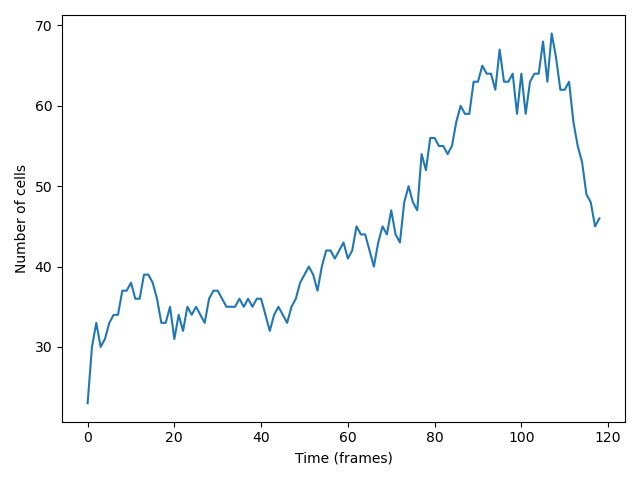

In [65]:
number_of_cells = []

fig = plt.figure()

for i in range(np.max(df['FRAME'])):
    df_frame = df[df["FRAME"]==i]
    number_of_cells.append(len(df_frame[df_frame["AREA"]>2000]))

plt.plot([i for i in range(np.max(df['FRAME']))], number_of_cells)
# plt.xlim(0, 150
# plt.ylim(40, 60)
plt.xlabel('Time (frames)')
plt.ylabel('Number of cells')
plt.tight_layout()
plt.show()

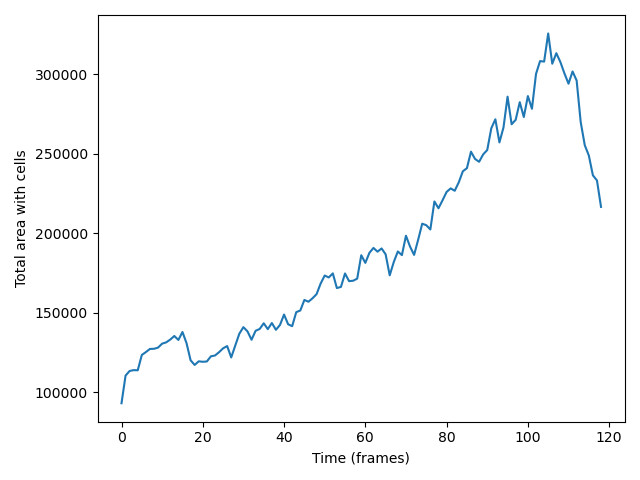

In [66]:
area_with_cells = []

fig = plt.figure()

for i in range(np.max(df['FRAME'])):
    df_frame = df[df["FRAME"]==i]
    area_with_cells.append(sum(df_frame.loc[df_frame["FRAME"]==i, "AREA"]))

plt.plot([i for i in range(np.max(df['FRAME']))], area_with_cells)
# plt.xlim(0, 150)
# plt.ylim(150000, 350000)
plt.xlabel('Time (frames)')
plt.ylabel('Total area with cells')
plt.tight_layout()
plt.show()

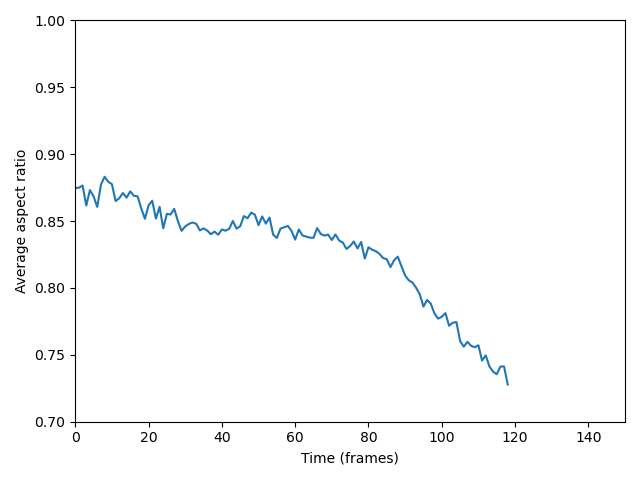

In [67]:
avg_aspect_ratio = []

fig = plt.figure()

for i in range(np.max(df['FRAME'])):
    avg_aspect_ratio.append(np.average(df.loc[df["FRAME"]==i, "CIRCULARITY"]))

plt.plot([i for i in range(np.max(df['FRAME']))], avg_aspect_ratio)
plt.xlim(0, 150)
plt.ylim(0.7, 1)
plt.xlabel('Time (frames)')
plt.ylabel('Average aspect ratio')
plt.tight_layout()
plt.show()

# Cellpose data

In [68]:
filepaths_cp = [f'/Volumes/phy/Gladfelter_rotation/Michael_Ursa/20240620_NaCl-gradient_24hr/3_results/s01_overnight_C_5NaCl_10NaCl_P{p}/morphology_params.csv' for p in range(1, 10)]

df_cp_all = pd.DataFrame()

for i in range(len(filepaths_cp)):
    df_cp = pd.read_csv(filepaths_cp[i], skiprows=[1, 2, 3])
    df_cp["FRAME"] = [int(df_cp['image'].values[i].split('-')[1][:4]) for i in range(len(df_cp))]
    df_cp['POSITION'] = i+1
    df_cp_all = pd.concat((df_cp_all, df_cp))

df_cp_all

,Unnamed: 0,label,area,axis_major_length,axis_minor_length,centroid-0,centroid-1,orientation,image,mutant,aspect_ratio,FRAME,POSITION
0,3,4,1644.0,56.231381,37.292098,47.831509,436.587591,1.566199,s01_overnight_C_5NaCl_10NaCl_P1-0001_subtr_bkg,overnight,0.663190,1,1
1,4,5,1404.0,46.342320,38.729677,133.534900,965.437322,0.809816,s01_overnight_C_5NaCl_10NaCl_P1-0001_subtr_bkg,overnight,0.835730,1,1
2,5,6,1172.0,42.634577,35.104017,181.142491,1515.025597,1.485694,s01_overnight_C_5NaCl_10NaCl_P1-0001_subtr_bkg,overnight,0.823370,1,1
3,6,7,1752.0,59.119794,39.694751,195.347603,278.974315,0.616260,s01_overnight_C_5NaCl_10NaCl_P1-0001_subtr_bkg,overnight,0.671429,1,1
4,7,8,181.0,20.765092,11.572378,211.182320,302.751381,0.506298,s01_overnight_C_5NaCl_10NaCl_P1-0001_subtr_bkg,overnight,0.557300,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18970,79,80,3250.0,88.675948,47.568302,1920.402154,1545.071692,1.063687,s01_overnight_C_5NaCl_10NaCl_P9-0220_subtr_bkg,overnight,0.536428,220,9
18971,80,81,1583.0,51.664704,39.039425,1944.756791,478.370183,0.860766,s01_overnight_C_5NaCl_10NaCl_P9-0220_subtr_bkg,overnight,0.755630,220,9
18972,81,82,809.0,51.818320,20.565632,1940.498146,46.969098,1.267655,s01_overnight_C_5NaCl_10NaCl_P9-0220_subtr_bkg,overnight,0.396880,220,9
18973,82,83,1861.0,56.924208,41.705083,1957.239656,172.315422,0.981437,s01_overnight_C_5NaCl_10NaCl_P9-0220_subtr_bkg,overnight,0.732642,220,9


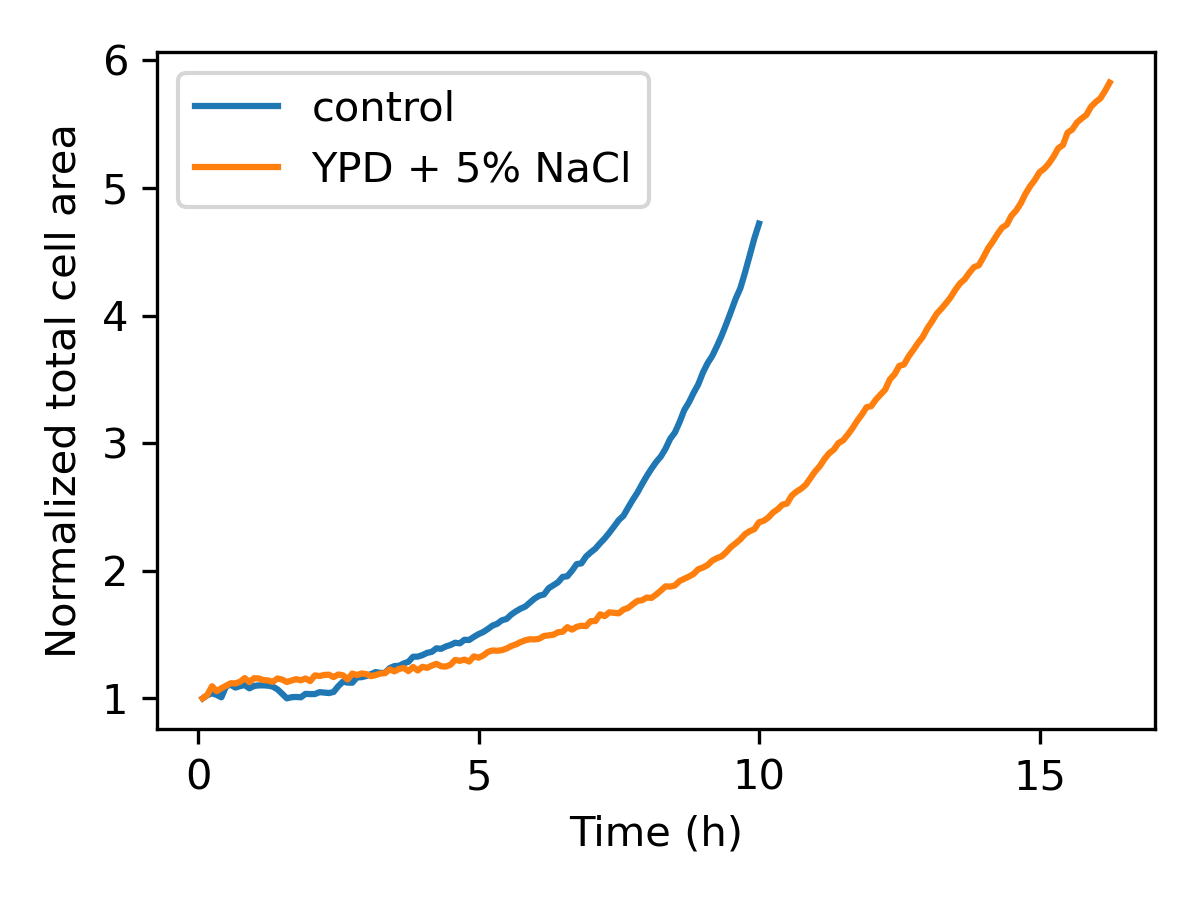

In [82]:
total_area_P1 = []
total_area_P4 = []
total_area_P7 = []
total_area_P1 = []
total_area_P4 = []
total_area_P7 = []
frames = []

for i in df_cp["FRAME"].unique():
    frames.append(i)
    if (np.sum(df_cp_all.loc[(df_cp_all["FRAME"]==i)&(df_cp_all["POSITION"]==1), "area"])) != 0:
        total_area_P1.append(np.sum(df_cp_all.loc[(df_cp_all["FRAME"]==i)&(df_cp_all["POSITION"]==1), "area"]))
    if (np.sum(df_cp_all.loc[(df_cp_all["FRAME"]==i)&(df_cp_all["POSITION"]==4), "area"])) != 0:
        total_area_P4.append(np.sum(df_cp_all.loc[(df_cp_all["FRAME"]==i)&(df_cp_all["POSITION"]==4), "area"]))
    if (np.sum(df_cp_all.loc[(df_cp_all["FRAME"]==i)&(df_cp_all["POSITION"]==7), "area"])) != 0:
        total_area_P7.append(np.sum(df_cp_all.loc[(df_cp_all["FRAME"]==i)&(df_cp_all["POSITION"]==7), "area"]))


fig = plt.figure(figsize=(4, 3), dpi=300)
plt.plot(np.array(frames[: len(total_area_P1)])*5/60, total_area_P1/total_area_P1[0], label = 'control')
plt.plot(np.array(frames[:len(total_area_P4)])*5/60, total_area_P4/total_area_P4[0],  label = 'YPD + 5% NaCl')
# plt.plot(np.array(frames[:len(total_area_P7)])*5/60, total_area_P7/total_area_P7[0], label = 'YPD + 10% NaCl')

plt.ylabel('Normalized total cell area')
plt.xlabel('Time (h)')
plt.legend()
plt.tight_layout()
plt.show()



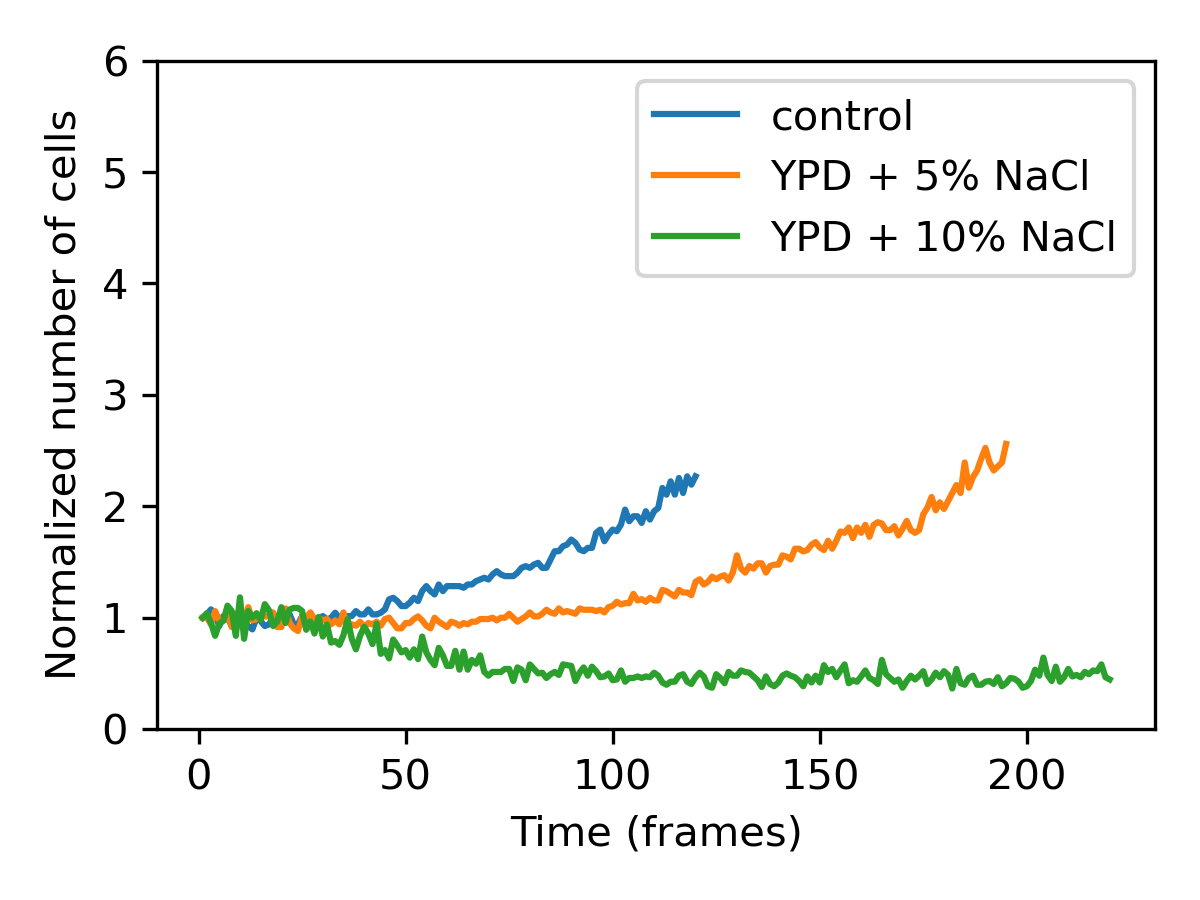

In [ ]:
total_n_cells_P1 = []
total_n_cells_P4 = []
total_n_cells_P7 = []
total_n_cells_P1 = []
total_n_cells_P4 = []
total_n_cells_P7 = []
frames = []

for i in df_cp["FRAME"].unique():
    frames.append(i)
    if (np.sum(df_cp_all.loc[(df_cp_all["FRAME"]==i)&(df_cp_all["POSITION"]==1), "area"])) != 0:
        total_n_cells_P1.append(len(df_cp_all.loc[(df_cp_all["FRAME"]==i)&(df_cp_all["POSITION"]==1), "area"]))
    if (np.sum(df_cp_all.loc[(df_cp_all["FRAME"]==i)&(df_cp_all["POSITION"]==4), "area"])) != 0:
        total_n_cells_P4.append(len(df_cp_all.loc[(df_cp_all["FRAME"]==i)&(df_cp_all["POSITION"]==4), "area"]))
    if (np.sum(df_cp_all.loc[(df_cp_all["FRAME"]==i)&(df_cp_all["POSITION"]==7), "area"])) != 0:
        total_n_cells_P7.append(len(df_cp_all.loc[(df_cp_all["FRAME"]==i)&(df_cp_all["POSITION"]==7), "area"]))


fig = plt.figure(figsize=(4, 3), dpi=300)
plt.plot(frames[:len(total_n_cells_P1)], np.asarray(total_n_cells_P1)/total_n_cells_P1[0], label = 'control')
plt.plot(frames[:len(total_n_cells_P4)], np.asarray(total_n_cells_P4)/total_n_cells_P4[0], label = 'YPD + 5% NaCl')
plt.plot(frames[:len(total_n_cells_P7)], np.asarray(total_n_cells_P7)/total_n_cells_P7[0], label = 'YPD + 10% NaCl')

plt.ylabel('Normalized number of cells')
plt.xlabel('Time (frames)')
plt.legend()
plt.ylim(0, 6)
plt.tight_layout()
plt.show()

0
1
1
2
1
0.5
3
1
0.5
0.475
4
1
0.5
0.475
0.45
5
1
0.5
0.475
0.45
0.425
6
1
0.5
0.475
0.45
0.425
0.4
7
1
0.5
0.475
0.45
0.425
0.4
0.375
8
1
0.5
0.475
0.45
0.425
0.4
0.375
0.35
9
1
0.5
0.475
0.45
0.425
0.4
0.375
0.35
0.32499999999999996
10
1
0.5
0.475
0.45
0.425
0.4
0.375
0.35
0.32499999999999996
0.3
11
1
0.5
0.475
0.45
0.425
0.4
0.375
0.35
0.32499999999999996
0.3
0.275
12
1
0.5
0.475
0.45
0.425
0.4
0.375
0.35
0.32499999999999996
0.3
0.275
0.25
13
1
0.5
0.475
0.45
0.425
0.4
0.375
0.35
0.32499999999999996
0.3
0.275
0.25
0.22499999999999998
14
1
0.5
0.475
0.45
0.425
0.4
0.375
0.35
0.32499999999999996
0.3
0.275
0.25
0.22499999999999998
0.19999999999999996
15
1
0.5
0.475
0.45
0.425
0.4
0.375
0.35
0.32499999999999996
0.3
0.275
0.25
0.22499999999999998
0.19999999999999996
0.175
16
1
0.5
0.475
0.45
0.425
0.4
0.375
0.35
0.32499999999999996
0.3
0.275
0.25
0.22499999999999998
0.19999999999999996
0.175
0.14999999999999997
17
1
0.5
0.475
0.45
0.425
0.4
0.375
0.35
0.32499999999999996
0.3
0.275
0.25


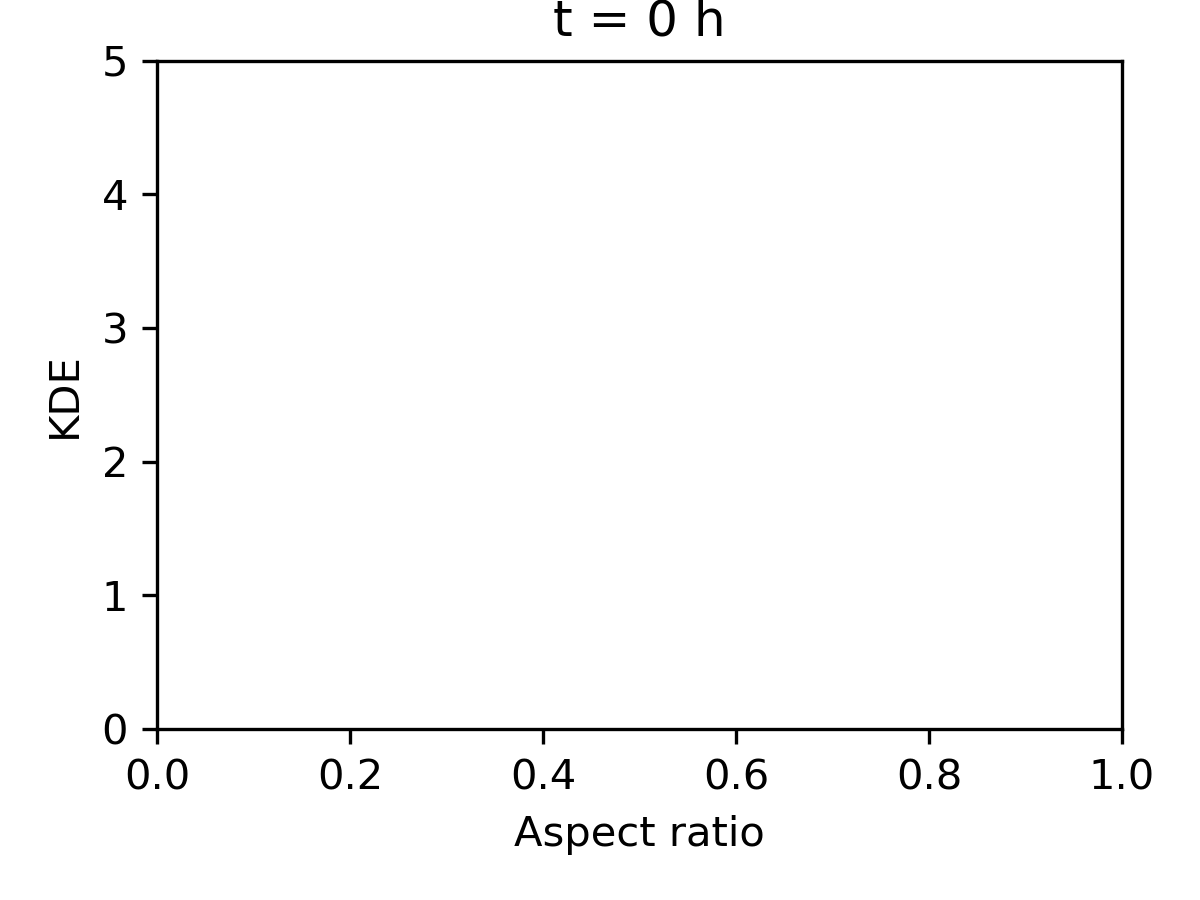

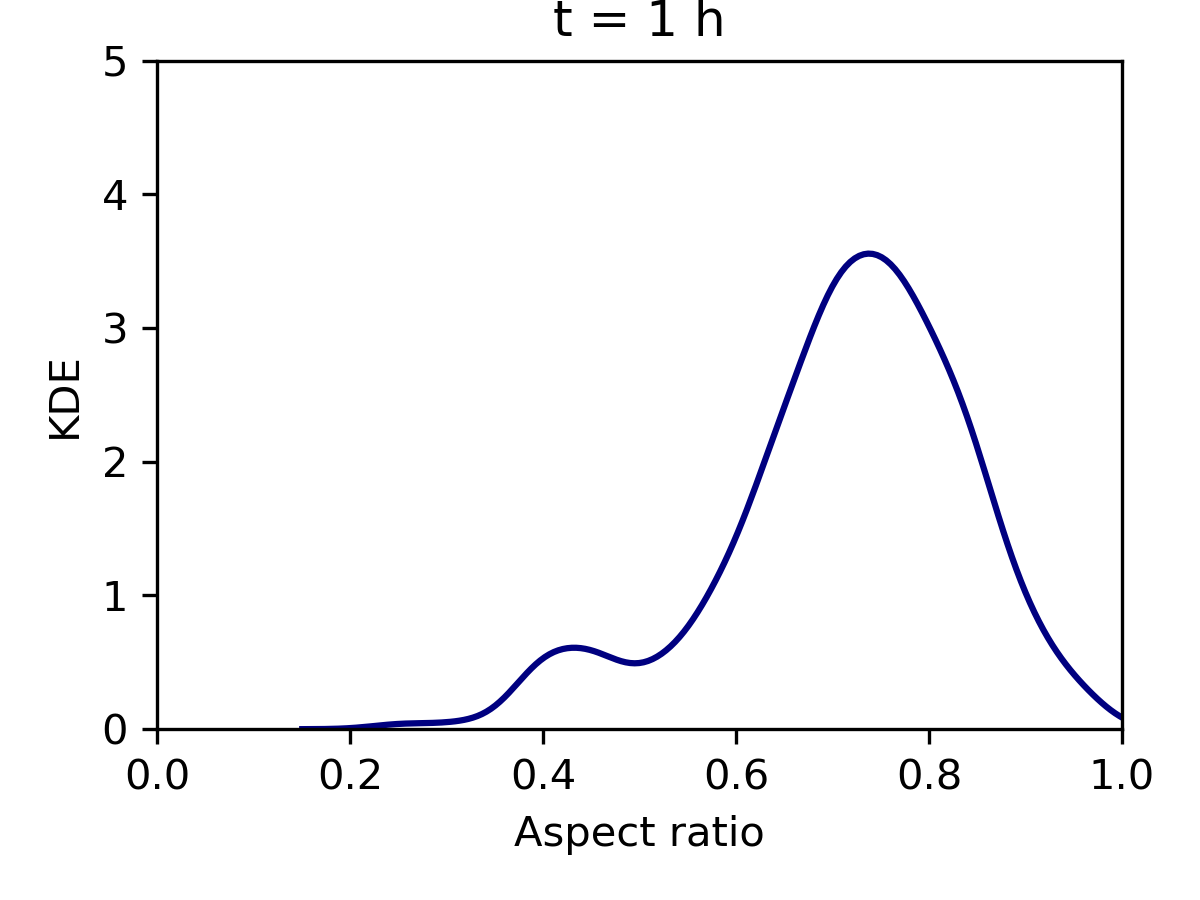

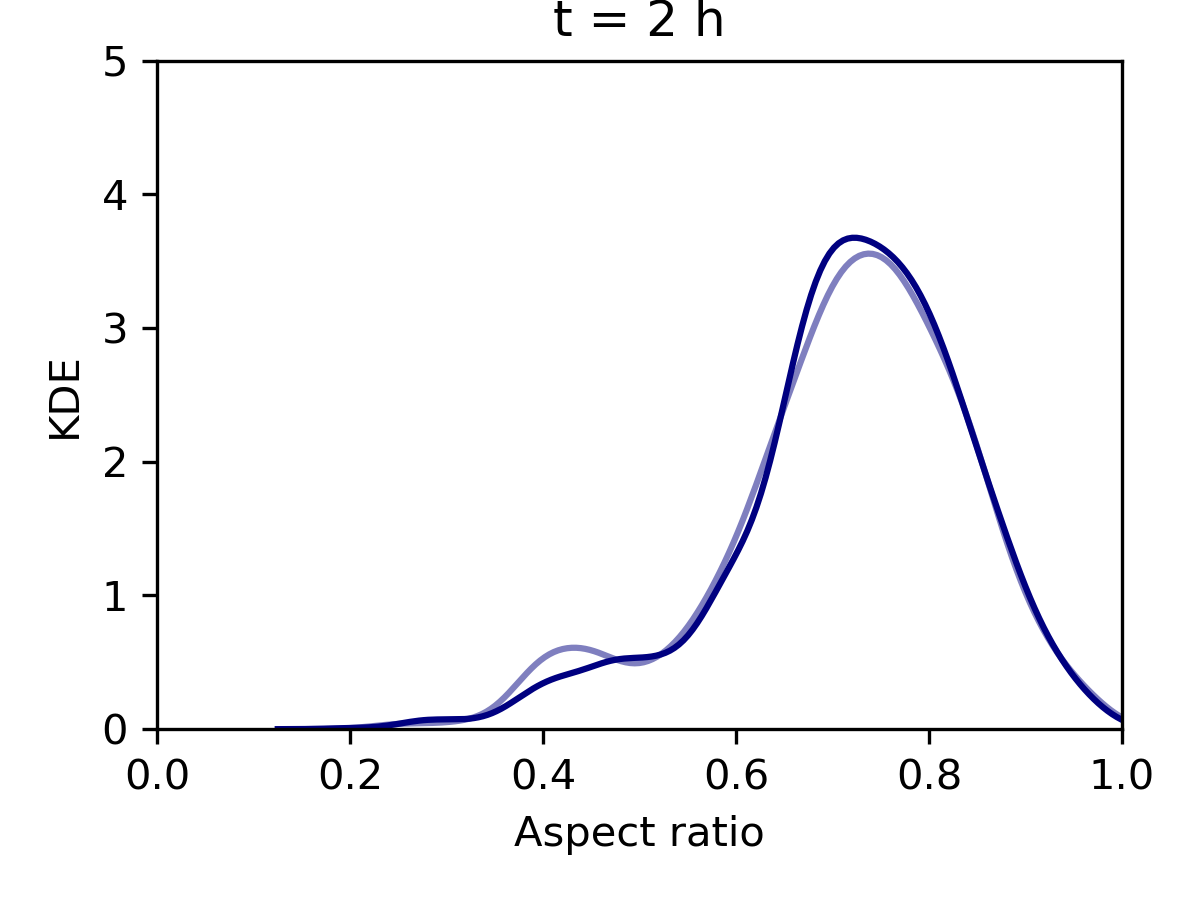

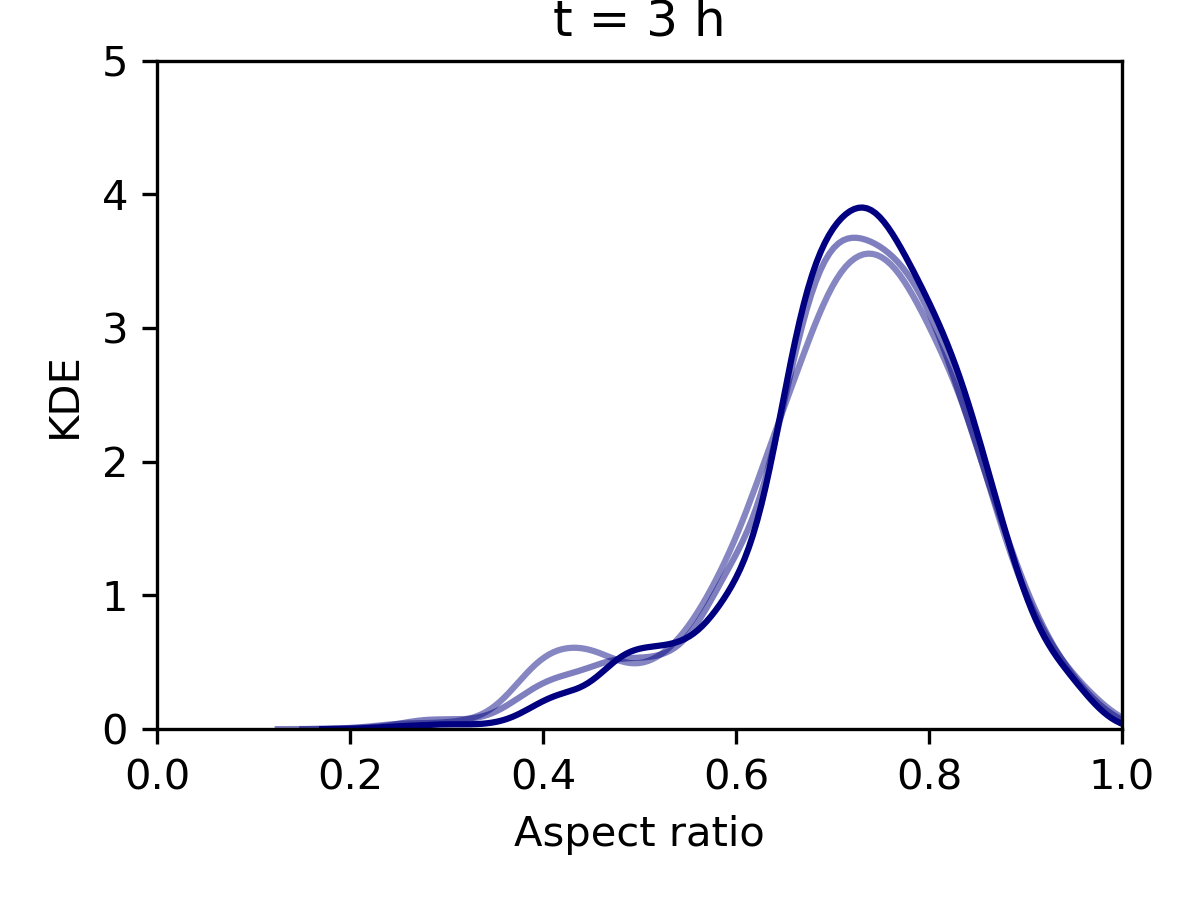

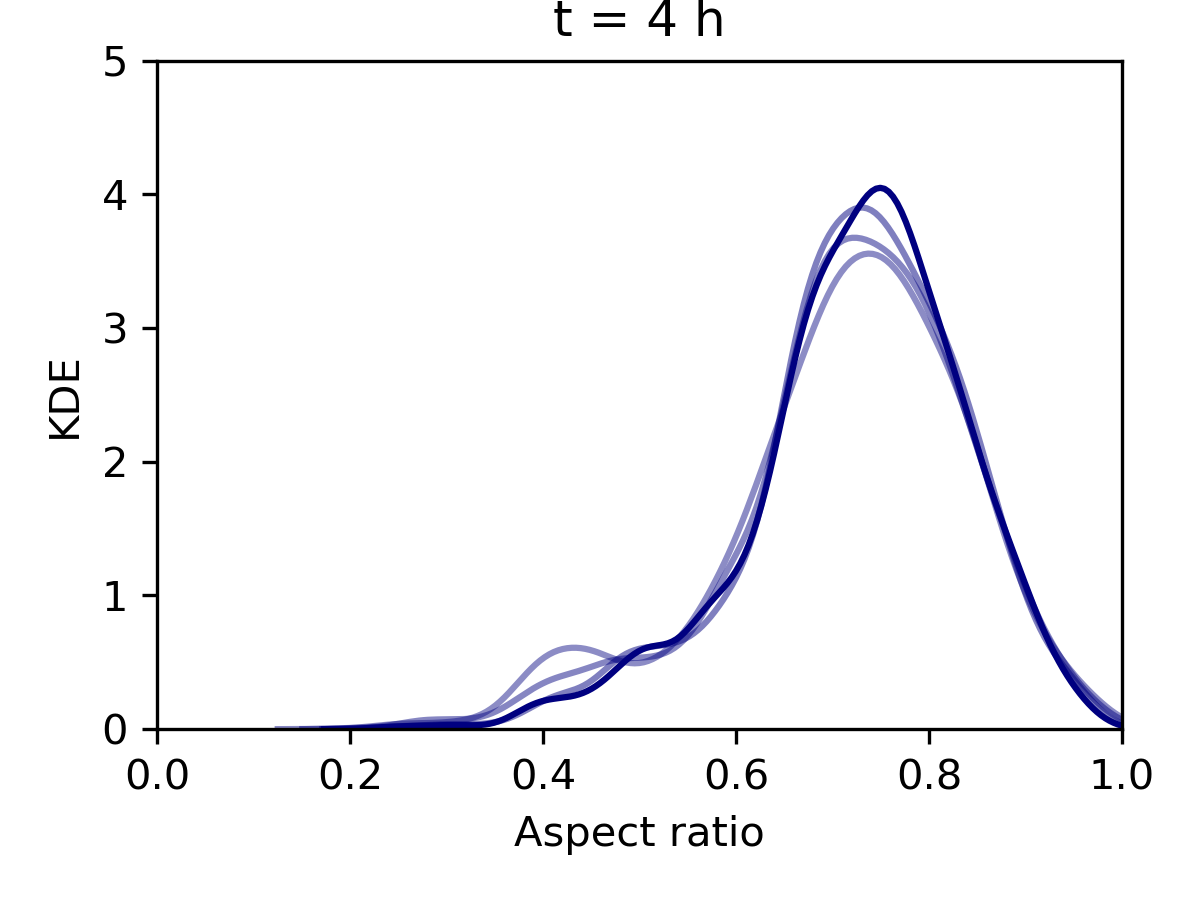

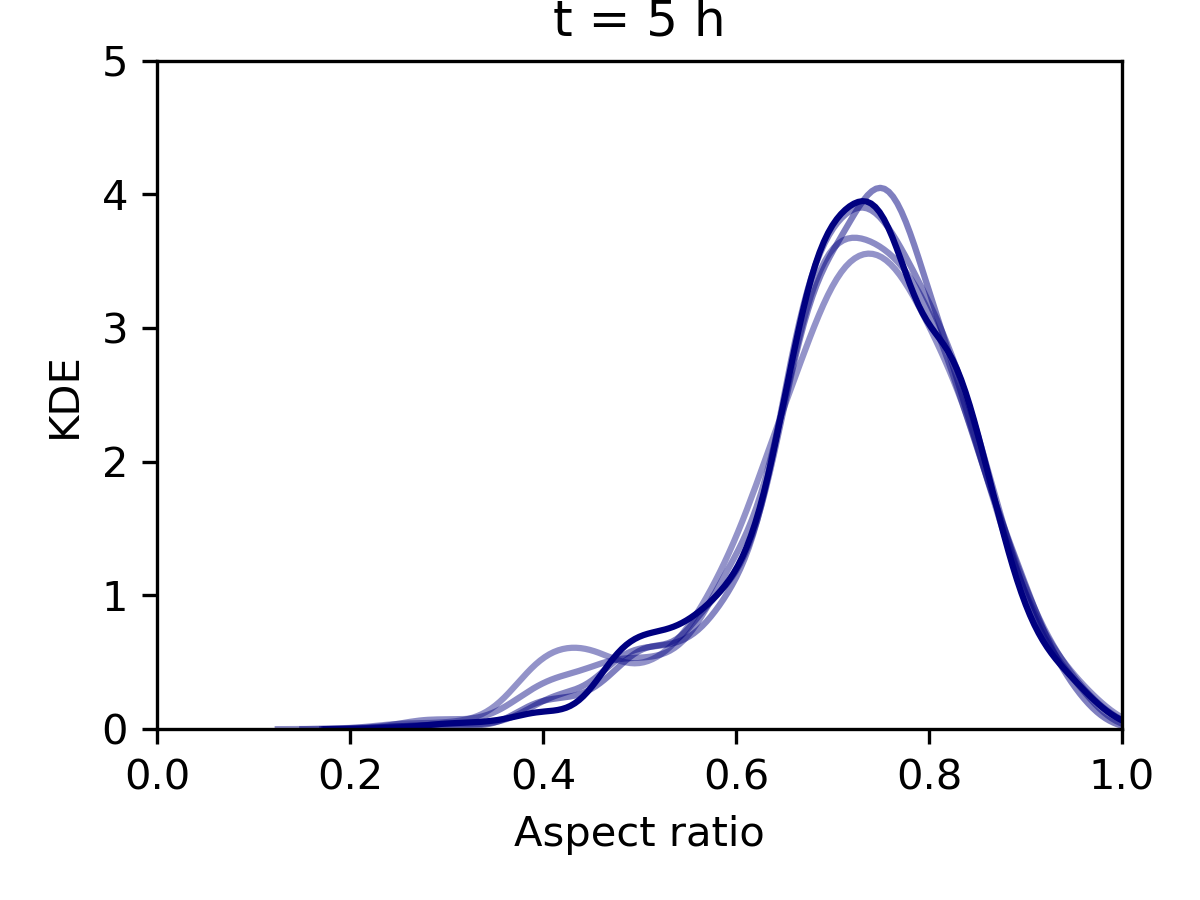

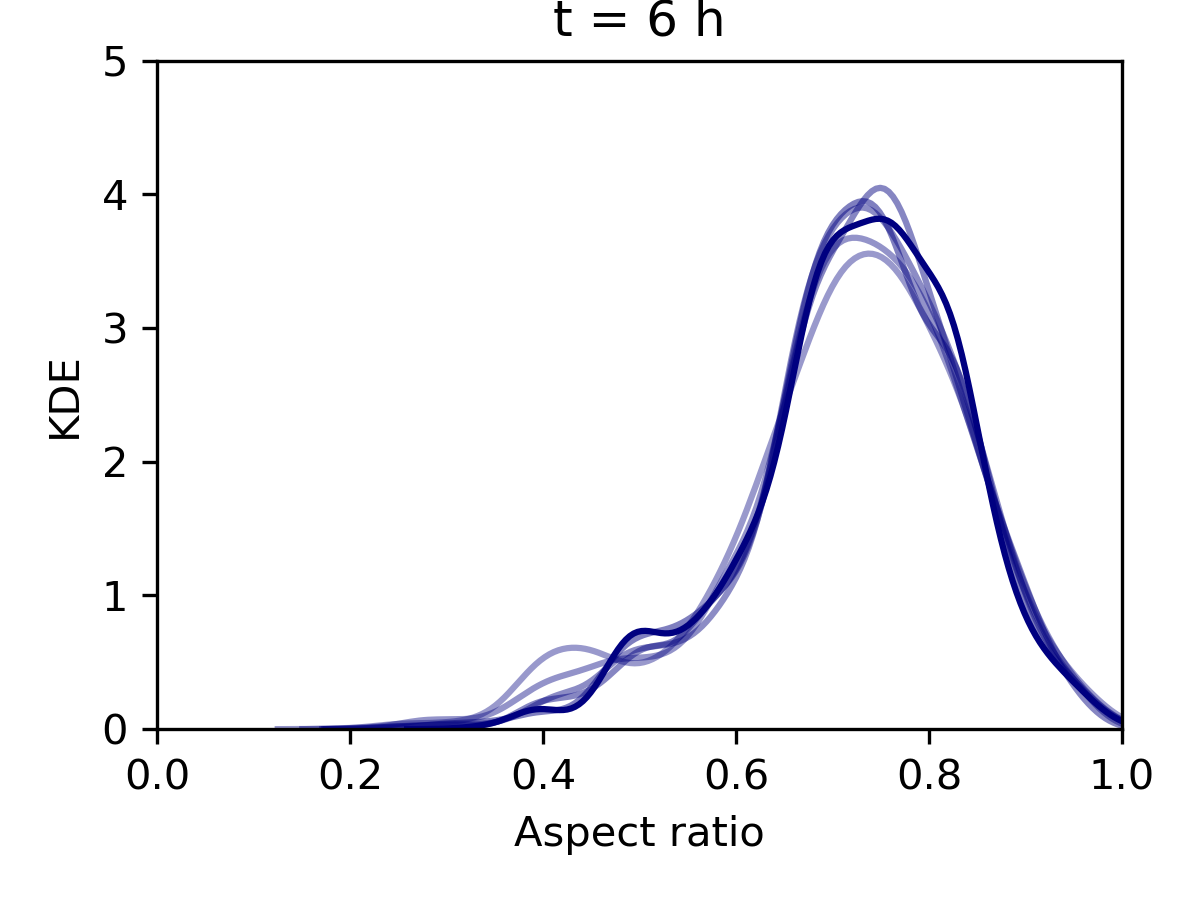

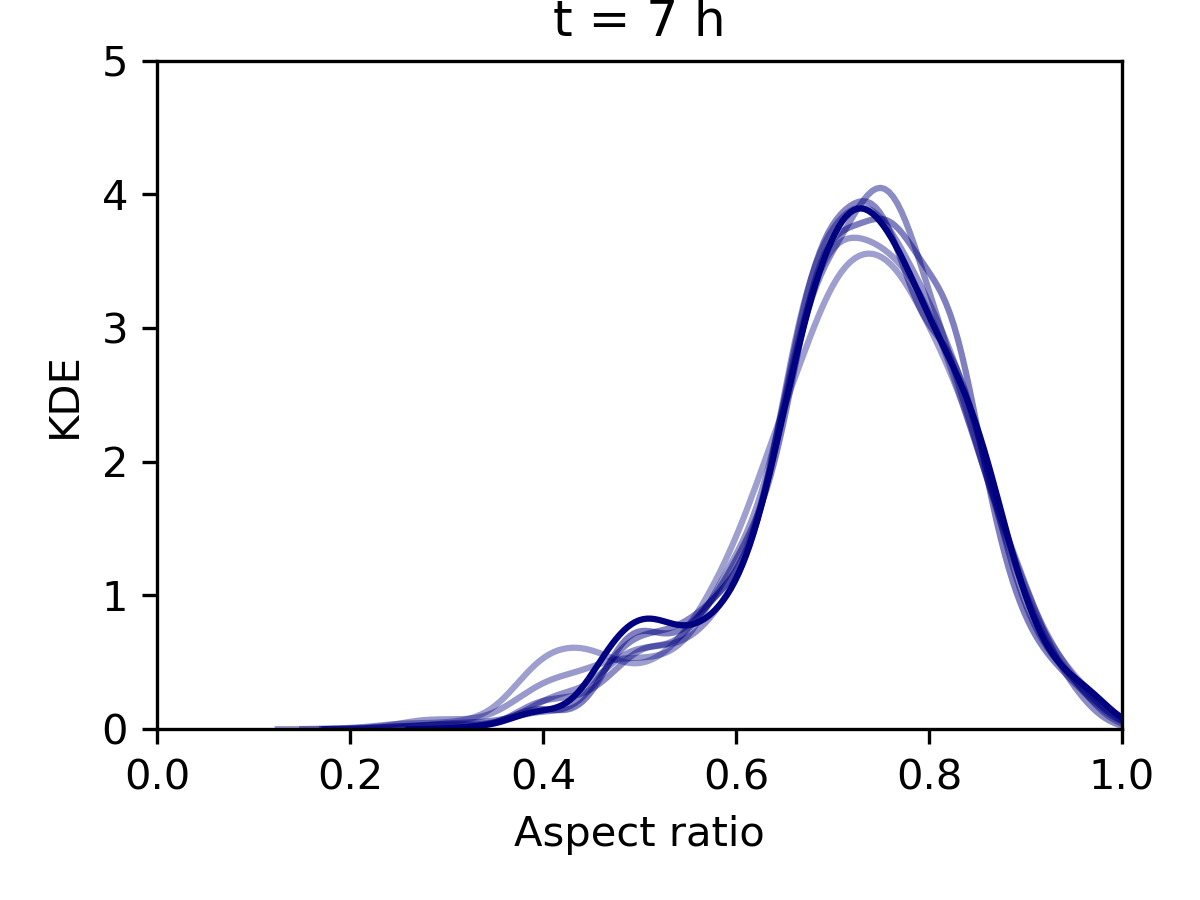

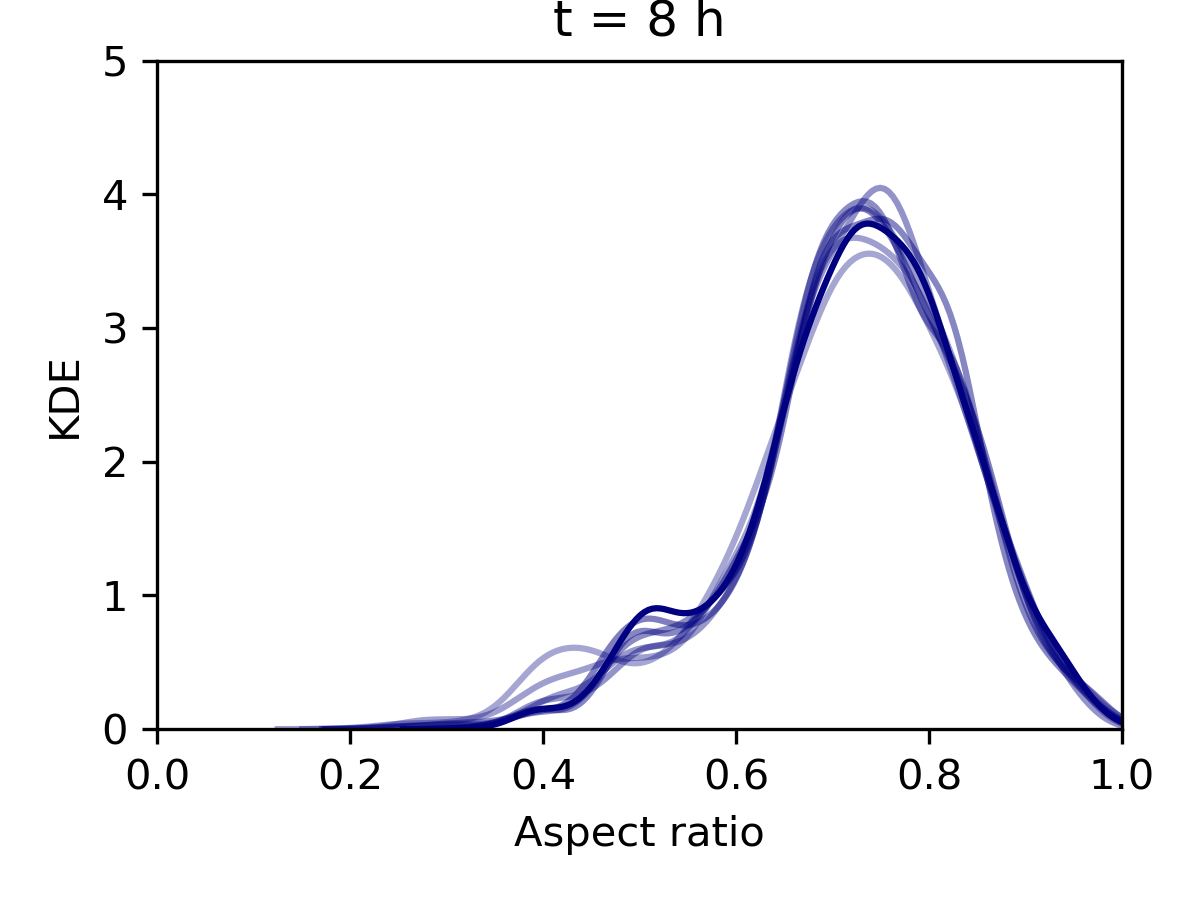

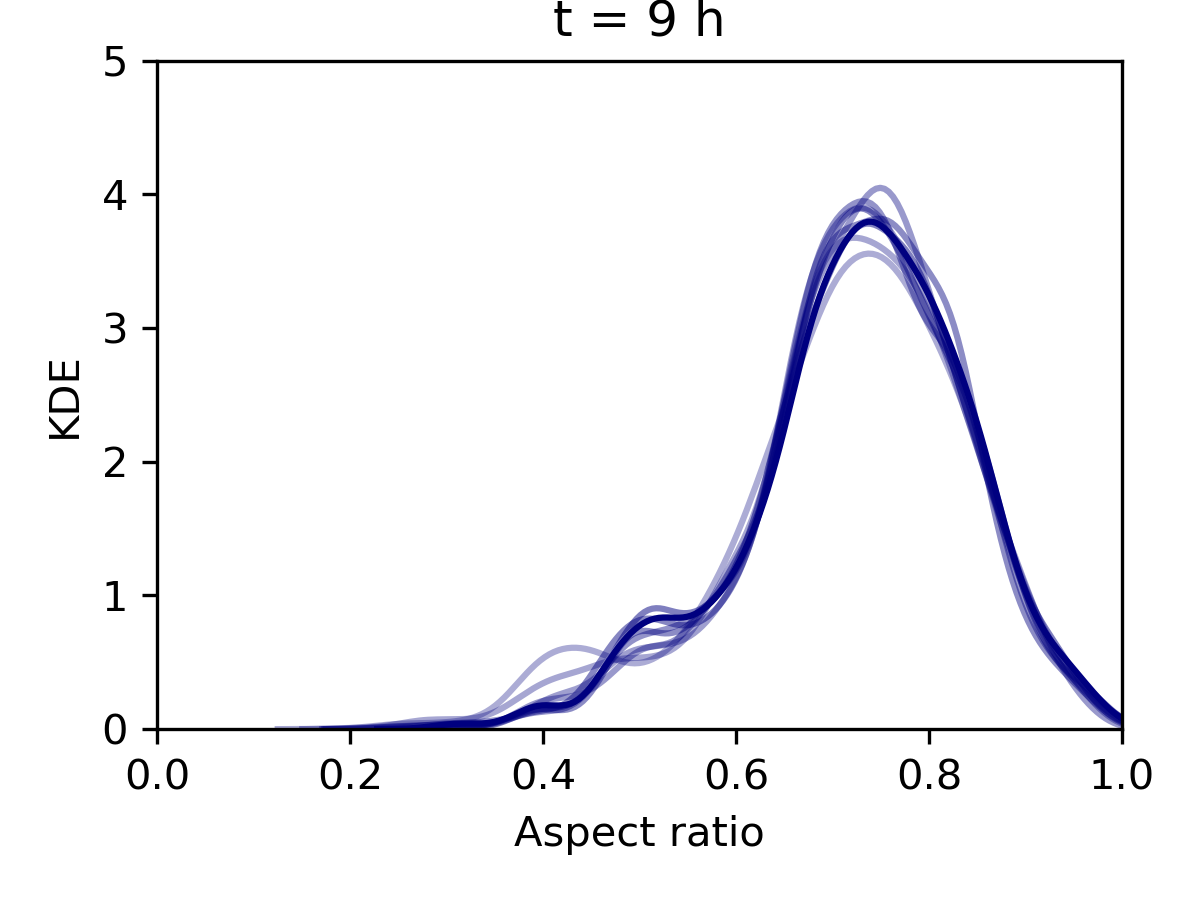

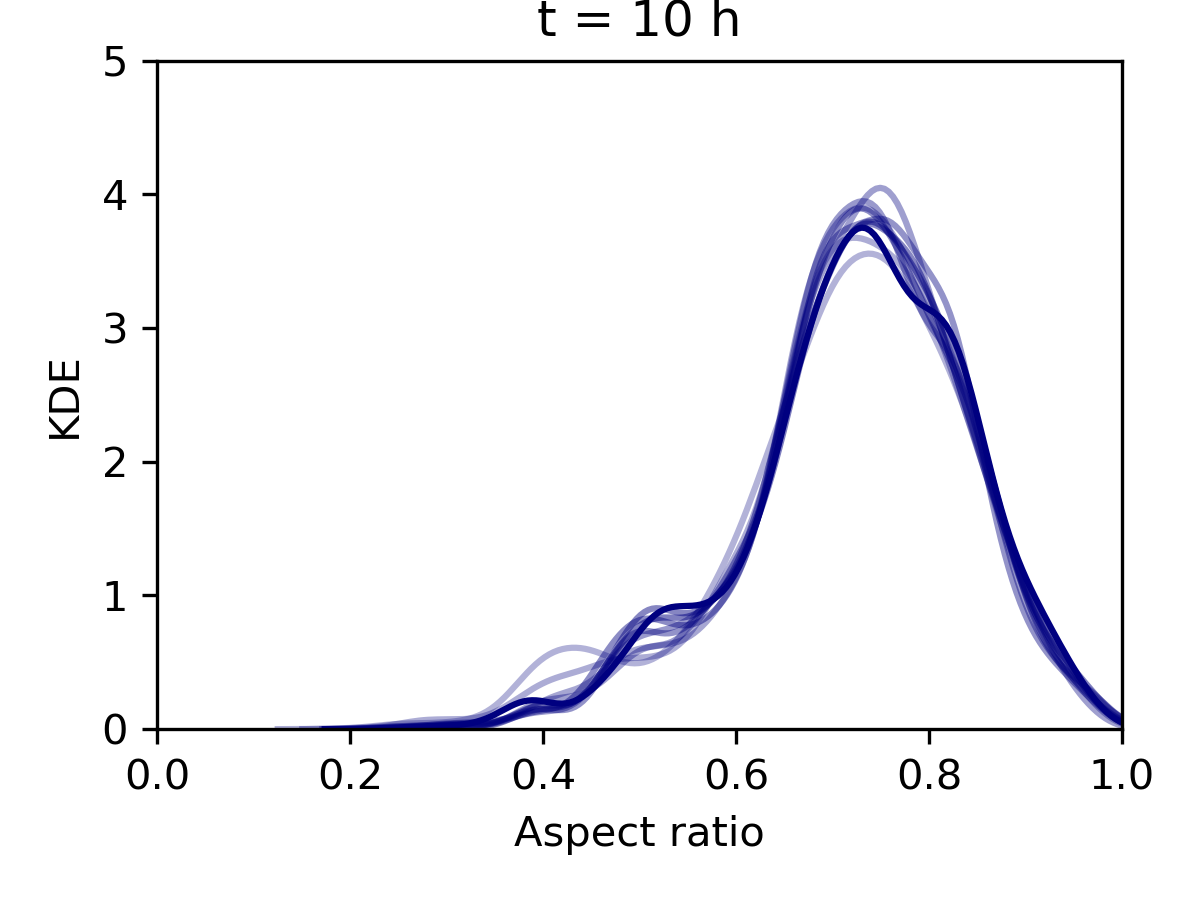

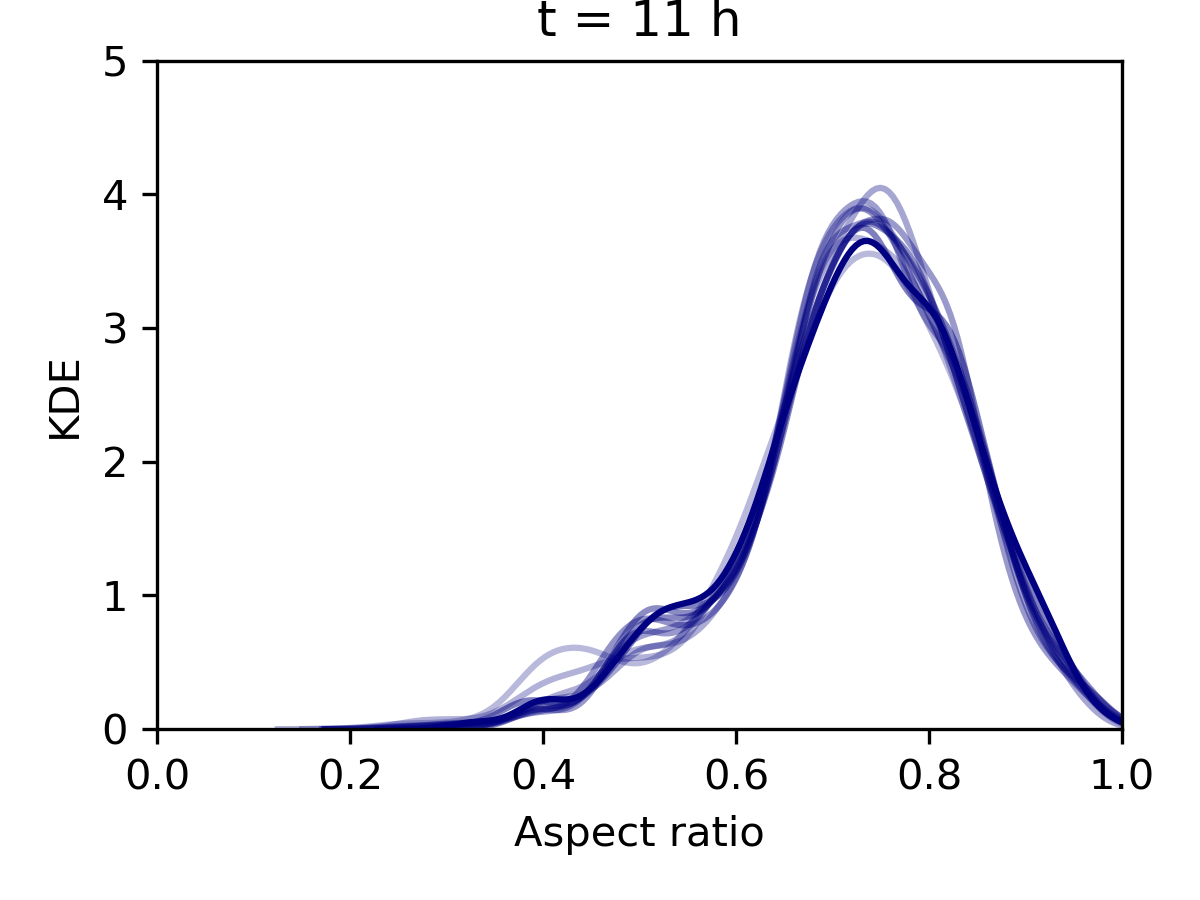

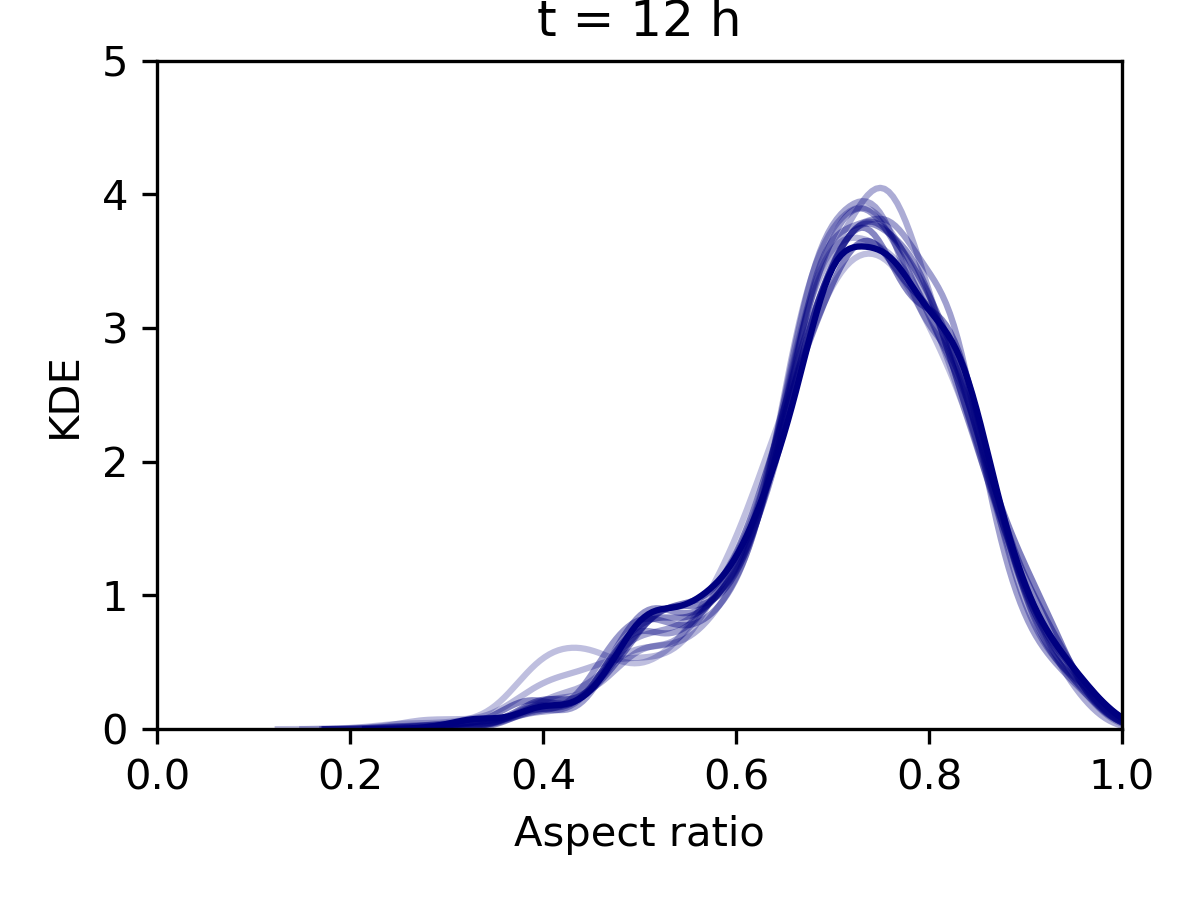

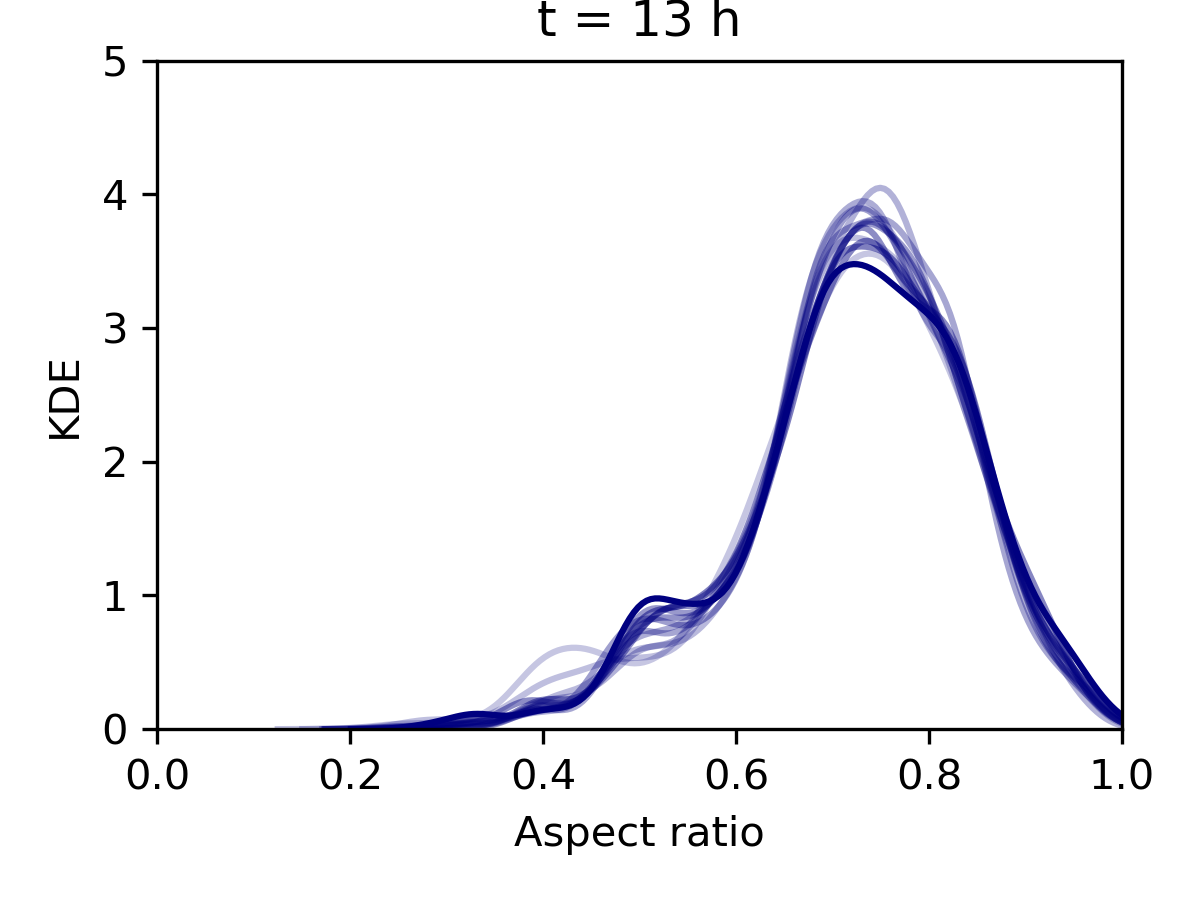

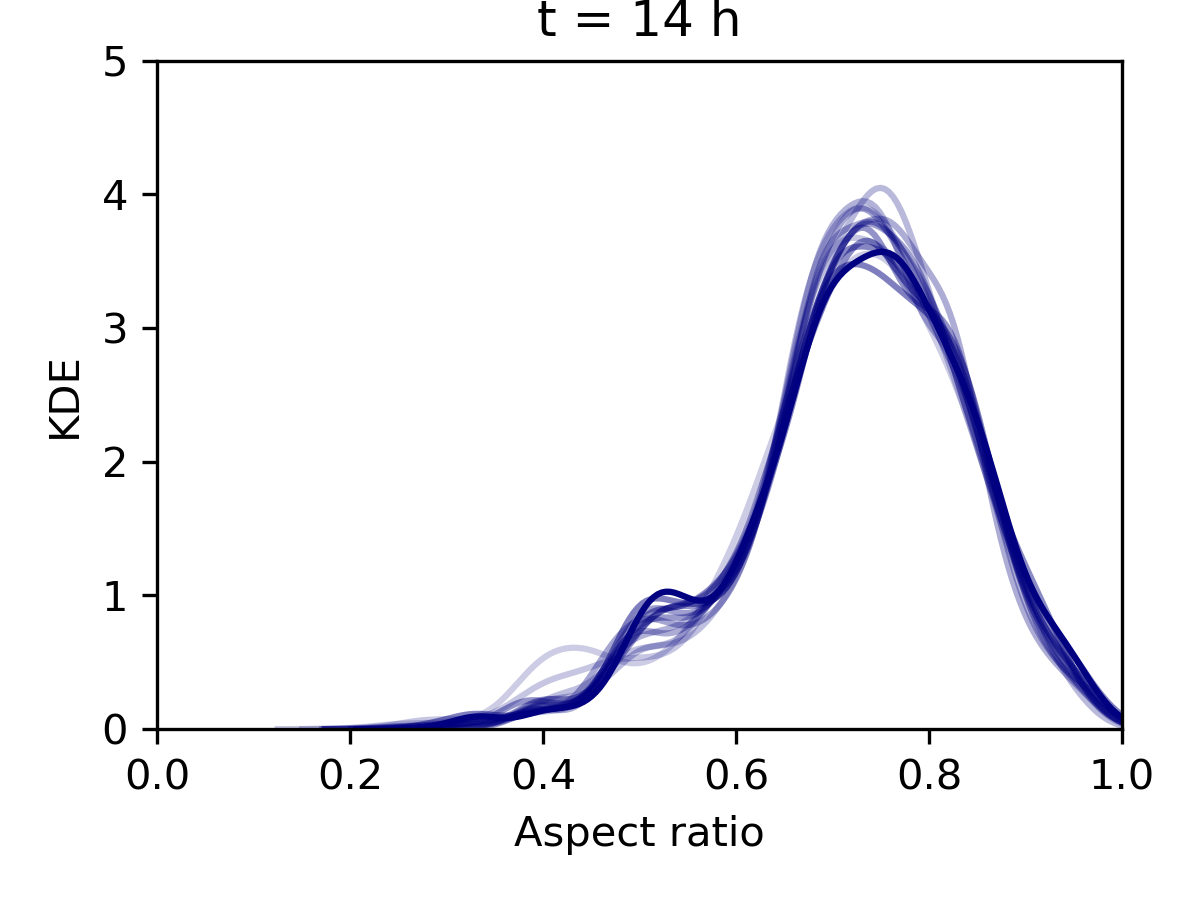

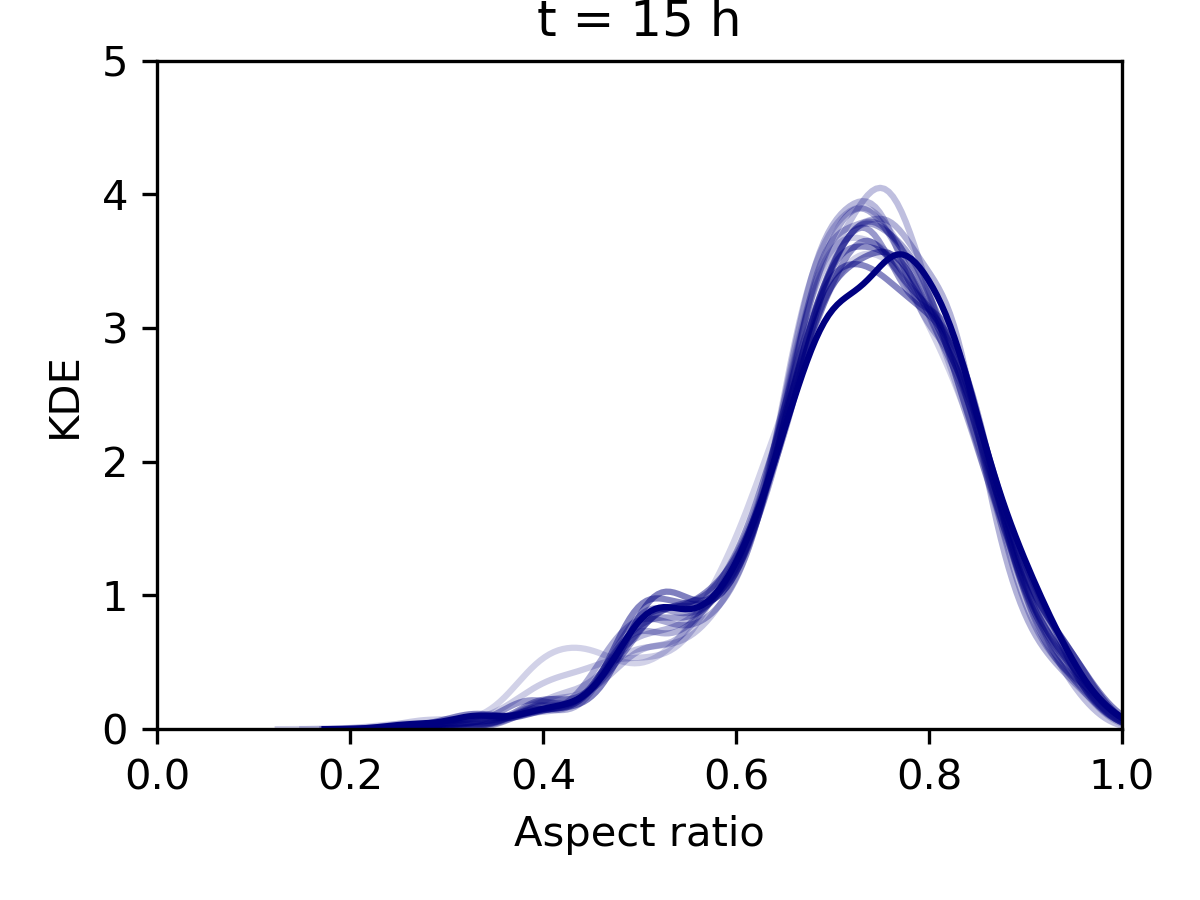

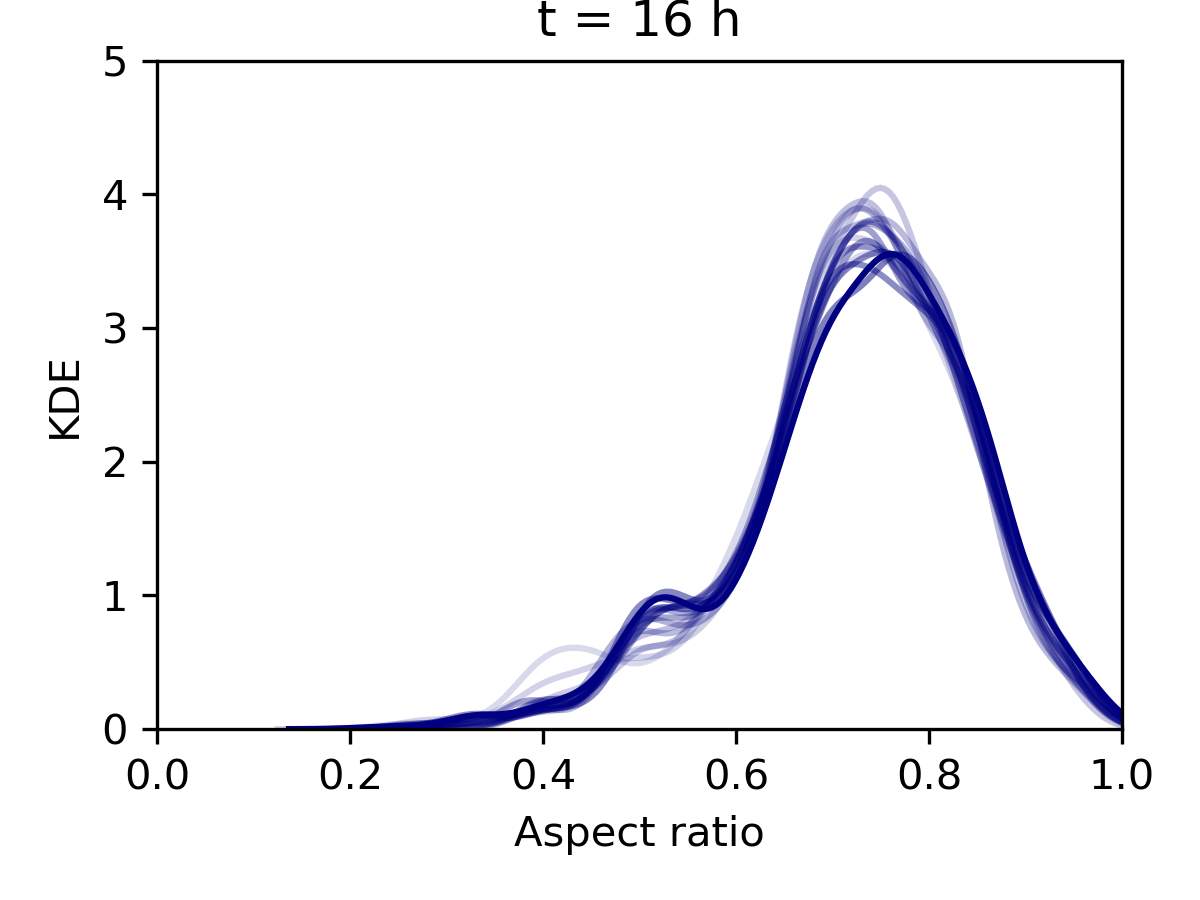

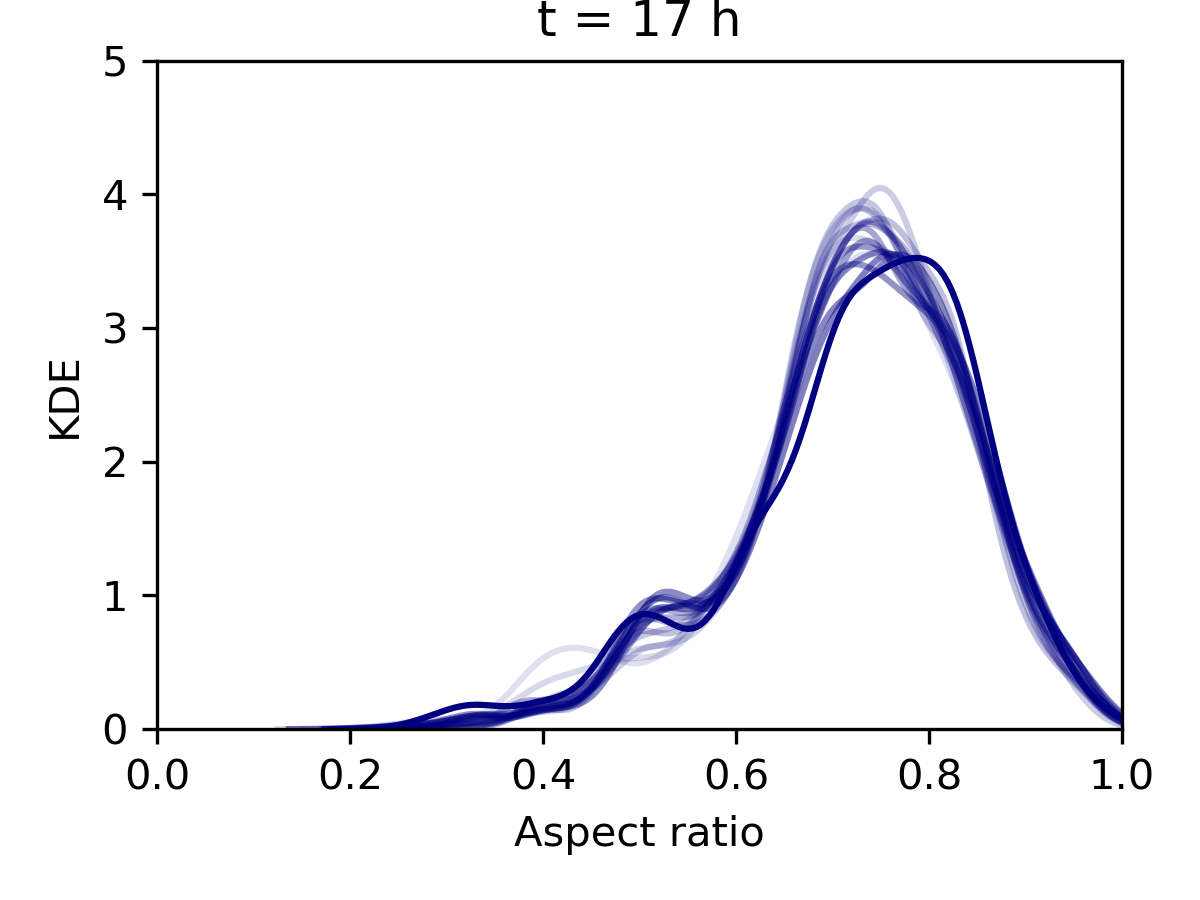

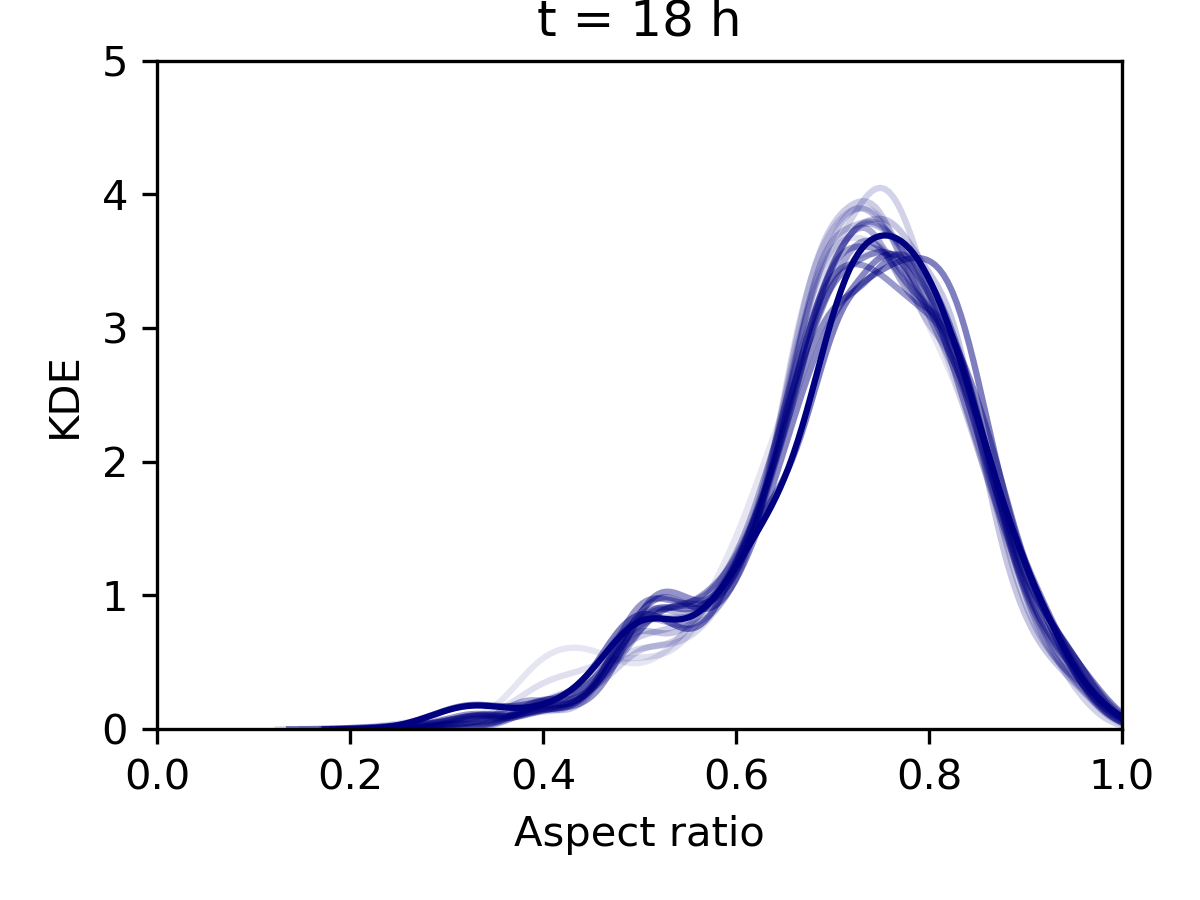

In [ ]:
P = 7
result_dir = f'/Volumes/phy/Gladfelter_rotation/Michael_Ursa/20240620_NaCl-gradient_24hr/3_results/'

df_cp_all = df_cp_all[df_cp_all["area"]>1000]
alphas = [1]
alphas = alphas + [0.5-0.025*j for j in range(20)]
for f in range(19):
    print(f)
    fig, ax = plt.subplots(figsize=(4, 3), dpi = 300)

    # plt.hist(data_aspect_ratio_P1)
    plt.ylabel('KDE')
    plt.xlabel('Aspect ratio')
    plt.xlim(0, 1)
    plt.ylim(0, 5)
    plt.tight_layout()
    for h in range(f):
        g = f-h
        data_aspect_ratio_P1 = df_cp_all.loc[(df_cp_all["FRAME"].isin([g*12 + i for i in range(12)]))&(df_cp_all["POSITION"].isin([P, P+1, P+2])), 'aspect_ratio']
        print(alphas[h])
        sns.kdeplot(np.array(data_aspect_ratio_P1), alpha = alphas[h], color='navy', ax=ax)
        
    plt.title(f't = {f} h')
    plt.savefig(result_dir + f'avg_aspect_ratio_P{P}all_{f}h.png')


In [ ]:
for P in [1, 4, 7]:
    print(len(df_cp_all.loc[(df_cp_all["FRAME"].isin([g*10 + i for i in range(10)]))&(df_cp_all["POSITION"].isin([P, P+1, P+2])), 'aspect_ratio']))

2690
2088
1655
